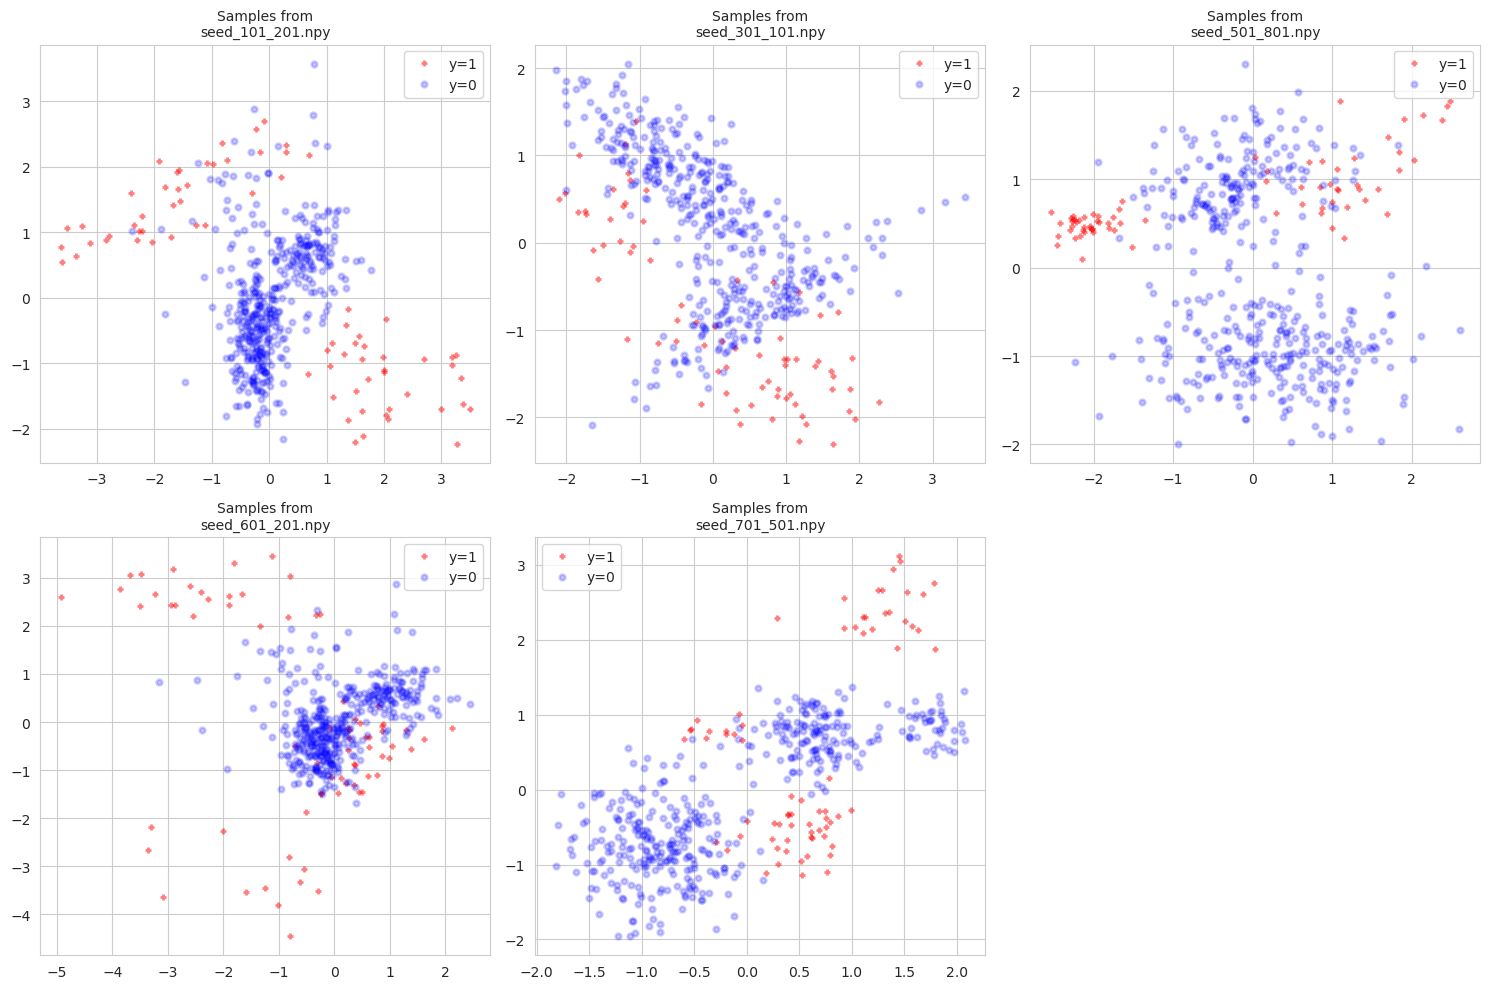

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

sns.set_style('whitegrid')

seeds = ['seed_101_201.npy', 'seed_301_101.npy', 'seed_501_801.npy', 'seed_601_201.npy', 'seed_701_501.npy']
xy500 = {}


# 1. Initialize the 2x3 grid and set overall window size
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# 2. Loop through both the data files and the grid subplots simultaneously
for seed, ax in zip(seeds, axs.flat):
    data_dict = np.load(seed, allow_pickle=True).item()

    x_N2 = data_dict['data']['x']
    y_N = data_dict['data']['y']

    random.seed(42)
    random_indices = random.sample(range(len(y_N)), 500)

    X_500 = x_N2[random_indices]
    y_500 = y_N[random_indices]
    xy500[seed] = (X_500, y_500)

    # 3. Direct the plot calls to the specific subplot 'ax'
    ax.plot(X_500[y_500 == 1, 0], X_500[y_500 == 1, 1], 'r+',
            mew=2, markersize=5, alpha=0.5, label='y=1')
    ax.plot(X_500[y_500 == 0, 0], X_500[y_500 == 0, 1], 'b.', 
            mew=2, markersize=8, alpha=0.2, label='y=0')
    
    # 4. Use ax-specific formatting methods
    ax.set_title(f"Samples from\n{seed}", fontsize=10)
    ax.legend(loc='best')

# 5. Hide the 6th subplot since you only have 5 seed files
axs.flat[-1].set_visible(False)

# 6. Prevent labels from overlapping and render the single grid figure
plt.tight_layout()
plt.show()


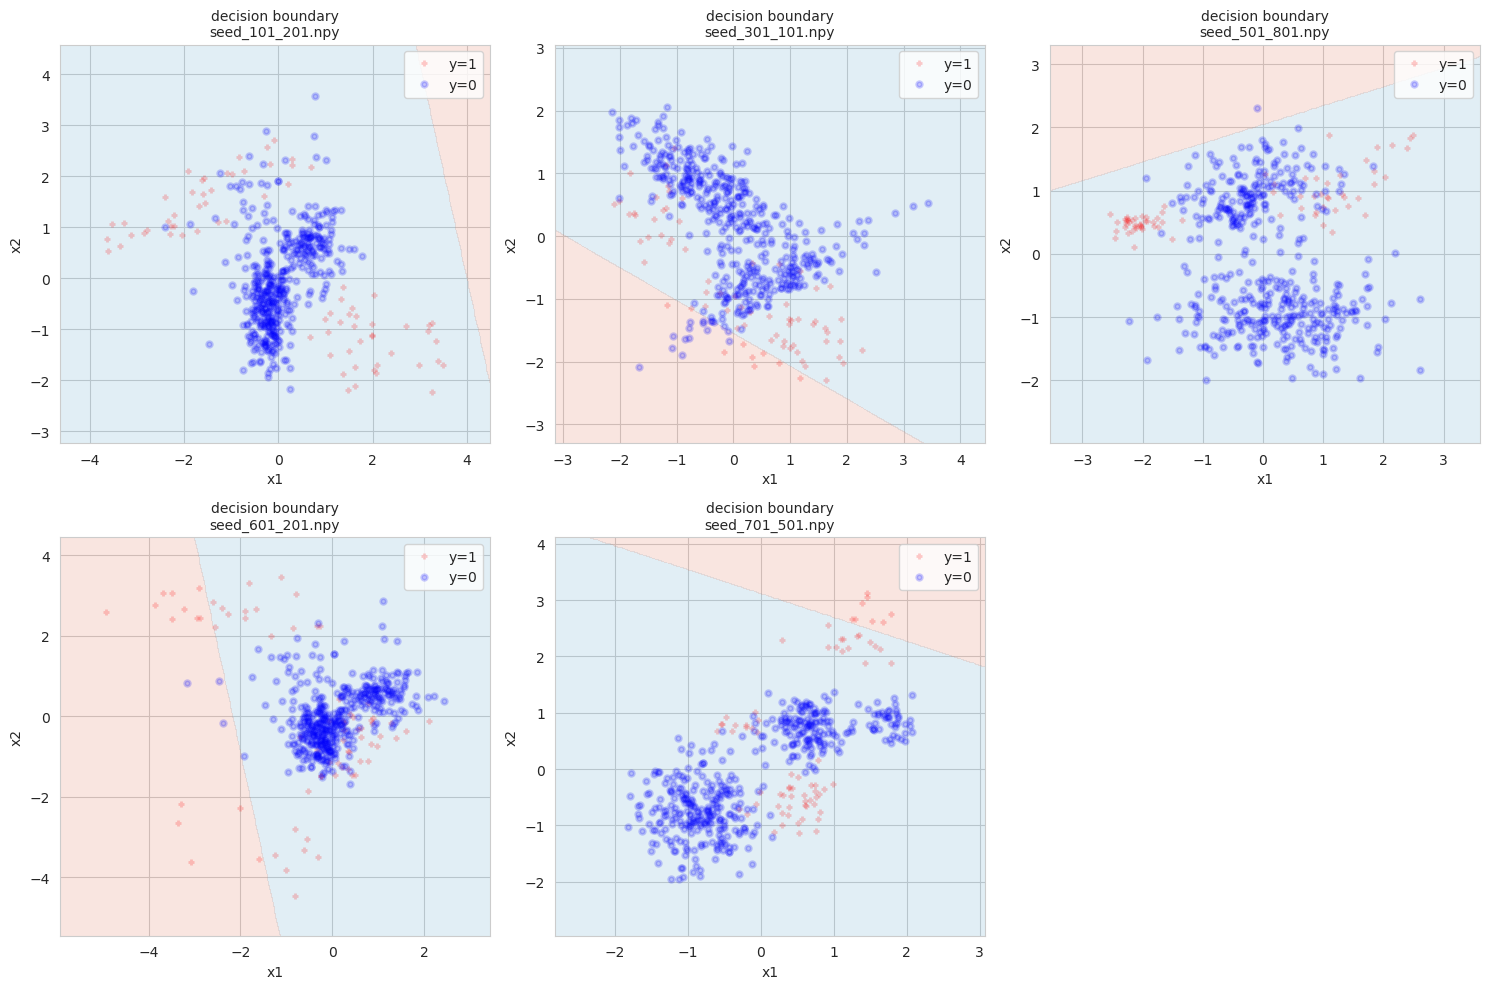

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

train_test = {}
clfs = {}

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

for ax, seed in zip(axs.flat, xy500):
    X_500, y_500 = xy500[seed]
    X_train, X_test, y_train, y_test = train_test_split(
        X_500, y_500, test_size=0.3, random_state=101, stratify=y_500)

    train_test[seed] = (X_train, X_test, y_train, y_test)

    clf = LogisticRegression(solver='lbfgs', max_iter=1000)
    clf.fit(X_train, y_train)

    clfs[seed] = clf

    y_pred = clf.predict(X_test)
    # print('Test accuracy:', accuracy_score(y_test, y_pred))
    # print(classification_report(y_test, y_pred))
    # print('Confusion matrix:')
    # print(confusion_matrix(y_test, y_pred))

    xx, yy = np.meshgrid(
        np.linspace(X_500[:, 0].min() - 1, X_500[:, 0].max() + 1, 500),
        np.linspace(X_500[:, 1].min() - 1, X_500[:, 1].max() + 1, 500)
    )
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, levels=[-0.5, 0.5, 1.5], cmap='RdBu_r')
    ax.plot(X_500[y_500 == 1, 0], X_500[y_500 == 1, 1], 'r+',
            mew=2, markersize=5, alpha=0.2, label='y=1')
    ax.plot(X_500[y_500 == 0, 0], X_500[y_500 == 0, 1], 'b.',
            mew=2, markersize=8, alpha=0.2, label='y=0')
    ax.legend()
    ax.set_title(f"decision boundary\n{seed}", fontsize=10)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

axs.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

(Moved heatmap code to slurm jobs)

In [3]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import roc_curve
# import _geometry  # Assuming this is your hard CPU geometry module

# # --- CHOOSE AN APPROPRIATE RESOLUTION ---
# # Drop the cost ratio grid points from 200 to 50 for the heatmap sweep.
# # A 50-point integration grid is visually identical on an image pixel map 
# # but cuts the geometric math overhead by exactly 75%.
# GRID_N_POINTS = 50 

# fig, axs = plt.subplots(2, 3, figsize=(15, 10))
# true_heatmaps = {}

# # Set up the strict hard bounds requested
# alpha = 0.6
# kappa_frac = 0.5
# min_ratio = 1/9
# max_ratio = 1/6

# for ax, seed in zip(axs.flat, clfs):
#     print(f"Processing split: {seed}...")
#     y_true = np.asarray(train_test[seed][3])
#     X_test = np.asarray(train_test[seed][1])
    
#     P = int(np.sum(y_true == 1))
#     N = int(np.sum(y_true == 0))
#     kappa = kappa_frac * float(len(y_true))

#     w1_center, w2_center = clfs[seed].coef_[0, 0], clfs[seed].coef_[0, 1]
#     intercept = float(clfs[seed].intercept_[0])

#     w1_vals = np.linspace(w1_center - 2, w1_center + 2, 30)
#     w2_vals = np.linspace(w2_center - 2, w2_center + 2, 30)

#     heatmap = np.zeros((len(w2_vals), len(w1_vals)), dtype=float)

#     # Fast loop over coefficients
#     for i, w2 in enumerate(w2_vals):
#         for j, w1 in enumerate(w1_vals):
#             # Compute raw linear activations and step probabilities
#             logits = X_test[:, 0] * w1 + X_test[:, 1] * w2 + intercept
#             y_pred = 1.0 / (1.0 + np.exp(-logits))
            
#             # Pure hard ROC generation via highly optimized C backend
#             fprs, tprs, thrs = roc_curve(y_true, y_pred)
            
#             # Run the constraints filter first
#             _, acc_fprs, acc_tprs, _, satisfy = _geometry._kept_on_valid(
#                 fprs, tprs, thrs, alpha, kappa, N, P
#             )
            
#             # SHORT-CIRCUIT: If constraints aren't satisfied, don't enter the geometry engine!
#             if satisfy:
#                 heatmap[i, j] = _geometry.voros(
#                     acc_fprs, acc_tprs, kappa, alpha, P, N,
#                     min_ratio, max_ratio, n_points=GRID_N_POINTS
#                 )
#             else:
#                 heatmap[i, j] = 0.0

#     true_heatmaps[seed] = heatmap
    
#     # --- Plotting Block ---
#     im = ax.imshow(
#         heatmap,
#         origin='lower',
#         extent=[w1_vals[0], w1_vals[-1], w2_vals[0], w2_vals[-1]],
#         aspect='auto',
#         cmap='viridis'
#     )
#     fig.colorbar(im, ax=ax, label='pVOROS score')
#     ax.set_xlabel('w1')
#     ax.set_ylabel('w2')
#     ax.set_title(f'pVOROS Heatmap (Hard Optimization): {seed}')
#     ax.scatter([w1_center], [w2_center], color='white', edgecolor='black', s=80, label='Trained Coefficients')
#     ax.legend(loc='upper right')

# axs.flat[-1].set_visible(False)
# plt.tight_layout()
# plt.show()

In [4]:
# from metrics import pvoros_score

# fig, axs = plt.subplots(2, 3, figsize=(15, 10))
# true_heatmaps = {}

# for ax, seed in zip(axs.flat, clfs):
#     print(seed)
#     y_true = train_test[seed][3]
#     X_test = train_test[seed][1]
#     def sigmoid(z):
#         return 1 / (1 + np.exp(-z))

#     w1_center, w2_center = clfs[seed].coef_[0, 0], clfs[seed].coef_[0, 1]
#     intercept = float(clfs[seed].intercept_[0])

#     w1_vals = np.linspace(w1_center - 2, w1_center + 2, 30)
#     w2_vals = np.linspace(w2_center - 2, w2_center + 2, 30)

#     heatmap = np.empty((len(w2_vals), len(w1_vals)), dtype=float)


#     W1, W2 = np.meshgrid(w1_vals, w2_vals)

#     x1 = X_test[:, 0][:, None, None]
#     x2 = X_test[:, 1][:, None, None]

#     Z = x1 * W1 + x2 * W2 + intercept
#     Y = sigmoid(Z)

#     for i, w2 in enumerate(w2_vals):
#         for j, w1 in enumerate(w1_vals):
#             heatmap[i, j] = pvoros_score(
#                 y_true,
#                 Y[:, i, j],
#                 alpha=0.6,
#                 kappa_frac=0.5,
#                 min_fp_cost_ratio=1/9,
#                 max_fp_cost_ratio=1/6,
#             )

#     true_heatmaps[seed] = heatmap
#     ax.imshow(
#     heatmap,
#     origin='lower',
#     extent=[w1_vals[0], w1_vals[-1], w2_vals[0], w2_vals[-1]],
#     aspect='auto',
#     cmap='viridis'
# )
#     im = ax.imshow(
#         heatmap,
#         origin='lower',
#         extent=[w1_vals[0], w1_vals[-1], w2_vals[0], w2_vals[-1]],
#         aspect='auto',
#         cmap='viridis'
#     )
#     fig.colorbar(im, ax=ax, label='pVOROS score')
#     ax.set_xlabel('w1')
#     ax.set_ylabel('w2')
#     ax.set_title('pVOROS score heatmap over x1/x2 coefficient grid')
#     ax.scatter([w1_center], [w2_center], color='white', edgecolor='black', s=80, label='trained coefficients')
#     ax.legend(loc='upper right')

# axs.flat[-1].set_visible(False)
# plt.tight_layout()
# plt.show()

In [5]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import roc_curve
# import _geometry

# fig, axs = plt.subplots(2, 3, figsize=(15, 10))
# true_heatmaps = {}

# # Set up global constraints 
# alpha = 0.6
# kappa_frac = 0.5
# min_ratio = 1/9
# max_ratio = 1/6

# for ax, seed in zip(axs.flat, clfs):
#     y_true = np.asarray(train_test[seed][3])
#     X_test = np.asarray(train_test[seed][1])
    
#     P = int(np.sum(y_true == 1))
#     N = int(np.sum(y_true == 0))
#     kappa = kappa_frac * float(len(y_true))

#     w1_center, w2_center = clfs[seed].coef_[0, 0], clfs[seed].coef_[0, 1]
#     intercept = float(clfs[seed].intercept_[0])

#     w1_vals = np.linspace(w1_center - 2, w1_center + 2, 30)
#     w2_vals = np.linspace(w2_center - 2, w2_center + 2, 30)
    
#     heatmap = np.zeros((len(w2_vals), len(w1_vals)), dtype=float)

#     # Sweep the weight grid
#     for i, w2 in enumerate(w2_vals):
#         for j, w1 in enumerate(w1_vals):
#             # 1. Direct logit computation
#             logits = X_test[:, 0] * w1 + X_test[:, 1] * w2 + intercept
#             y_pred = 1 / (1 + np.exp(-logits))
            
#             # 2. PURE HARD THRESHOLDING: Get crisp, non-smoothed step ROC curves
#             fprs, tprs, thrs = roc_curve(y_true, y_pred)
            
#             # 3. Filter using the exact sharp geometric bounds
#             _, acc_fprs, acc_tprs, _, satisfy = _geometry._kept_on_valid(
#                 fprs, tprs, thrs, alpha, kappa, N, P
#             )
            
#             # 4. Integrate if feasible, otherwise leave at 0.0
#             if satisfy:
#                 heatmap[i, j] = _geometry.voros(
#                     acc_fprs, acc_tprs, kappa, alpha, P, N,
#                     min_ratio, max_ratio, n_points=200
#                 )
#             else:
#                 heatmap[i, j] = 0.0

#     true_heatmaps[seed] = heatmap
    
#     # --- Plotting Block ---
#     im = ax.imshow(
#         heatmap,
#         origin='lower',
#         extent=[w1_vals[0], w1_vals[-1], w2_vals[0], w2_vals[-1]],
#         aspect='auto',
#         cmap='viridis'
#     )
#     fig.colorbar(im, ax=ax, label='pVOROS score')
#     ax.set_xlabel('w1')
#     ax.set_ylabel('w2')
#     ax.set_title(f'pVOROS Heatmap (Hard): {seed}')
#     ax.scatter([w1_center], [w2_center], color='white', edgecolor='black', s=80, label='Trained')
#     ax.legend(loc='upper right')

# axs.flat[-1].set_visible(False)
# plt.tight_layout()
# plt.show()

In [6]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import roc_curve
# import jax
# import jax.numpy as jnp
# import _geometry_jax  # Switch to your JAX-native geometry module

# # Force JAX to stay on CPU if you are running this in a basic terminal environment
# # jax.config.update('jax_platform_name', 'cpu')
# jax.config.update("jax_enable_x64", True)

# fig, axs = plt.subplots(2, 3, figsize=(15, 10))
# true_heatmaps = {}

# alpha = 0.6
# kappa_frac = 0.5
# min_ratio = 1/9
# max_ratio = 1/6

# for ax, seed in zip(axs.flat, clfs):
#     y_true_np = np.asarray(train_test[seed][3])
#     X_test_np = np.asarray(train_test[seed][1])
    
#     P = int(np.sum(y_true_np == 1))
#     N = int(np.sum(y_true_np == 0))
#     kappa = kappa_frac * float(len(y_true_np))

#     w1_center, w2_center = clfs[seed].coef_[0, 0], clfs[seed].coef_[0, 1]
#     intercept = float(clfs[seed].intercept_[0])

#     w1_vals = np.linspace(w1_center - 2, w1_center + 2, 30)
#     w2_vals = np.linspace(w2_center - 2, w2_center + 2, 30)
    
#     heatmap = np.zeros((len(w2_vals), len(w1_vals)), dtype=float)

#     for i, w2 in enumerate(w2_vals):
#         for j, w1 in enumerate(w1_vals):
#             # 1. Quick CPU prediction and crisp ROC extraction
#             logits = X_test_np[:, 0] * w1 + X_test_np[:, 1] * w2 + intercept
#             y_pred = 1 / (1 + np.exp(-logits))
#             fprs, tprs, thrs = roc_curve(y_true_np, y_pred)
            
#             # 2. Convert to JAX arrays to pass to your compiled geometry code
#             fprs_j = jnp.array(fprs, dtype=jnp.float64)
#             tprs_j = jnp.array(tprs, dtype=jnp.float64)
#             thrs_j = jnp.array(thrs, dtype=jnp.float64)
            
#             # 3. Use the JAX filtering function
#             _, acc_fprs, acc_tprs, _, satisfy = _geometry_jax._kept_on_valid(
#                 fprs_j, tprs_j, thrs_j, alpha, kappa, N, P
#             )
            
#             # 4. Integrate using the vectorized JAX layout (No Python loops!)
#             if satisfy:
#                 vor = _geometry_jax.voros_jax(
#                     acc_fprs, acc_tprs, kappa, alpha, P, N,
#                     min_ratio, max_ratio, n_points=200
#                 )
#                 heatmap[i, j] = float(vor)
#             else:
#                 heatmap[i, j] = 0.0

#     true_heatmaps[seed] = heatmap
    
#     # --- Plotting Block ---
#     im = ax.imshow(
#         heatmap,
#         origin='lower',
#         extent=[w1_vals[0], w1_vals[-1], w2_vals[0], w2_vals[-1]],
#         aspect='auto',
#         cmap='viridis'
#     )
#     fig.colorbar(im, ax=ax, label='pVOROS score')
#     ax.set_xlabel('w1')
#     ax.set_ylabel('w2')
#     ax.set_title(f'pVOROS Heatmap (JAX-Accelerated Hard): {seed}')
#     ax.scatter([w1_center], [w2_center], color='white', edgecolor='black', s=80, label='Trained')
#     ax.legend(loc='upper right')

# axs.flat[-1].set_visible(False)
# plt.tight_layout()
# plt.show()

In [7]:
# fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# for ax, seed in zip(axs.flat, true_heatmaps):
#     heatmap = true_heatmaps[seed]
#     ax.scatter(w1_vals, heatmap[15], color='tab:blue')
#     ax.set_xlabel('w1')
#     ax.set_ylabel('pVOROS score (fixed w2)')
#     ax.grid(alpha=0.3)
#     ax.set_title(f"pVOROS score vs w1\n{seed}", fontsize=10)

# axs.flat[-1].set_visible(False)
# plt.tight_layout()
# plt.show()

## Sigmoid Approximation

In [8]:
import numpy as np
import _geometry
from sklearn.metrics import roc_curve

ModuleNotFoundError: No module named '_geometry'

In [ ]:
def sigmoid_approximation(p, tau, k):
    return (1 + np.exp(-k * (p - tau))) ** -1

In [ ]:
def soft_set_sigmoid(y_true_N, y_pred_N, tau, k):
    y_true = np.asarray(y_true_N)
    y_pred = np.asarray(y_pred_N, dtype=float)
    soft_pred = sigmoid_approximation(y_pred, tau, k)

    pos_mask = y_true == 1
    neg_mask = y_true == 0

    tp = soft_pred[pos_mask].sum()
    fn = (1 - soft_pred[pos_mask]).sum()
    fp = soft_pred[neg_mask].sum()
    tn = (1 - soft_pred[neg_mask]).sum()

    return tp, fp, tn, fn

In [ ]:
def sigmoid_pvoros_score(y_true, y_pred, alpha, kappa_frac, min_fp_cost_ratio, max_fp_cost_ratio, k,
                         n_points=200):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    P = int(np.sum(y_true == 1))
    N = int(np.sum(y_true == 0))
    n = len(y_true)
    kappa = kappa_frac * float(n)

    _, _, thrs = roc_curve(y_true, y_pred)

    fprs = np.zeros(len(thrs), dtype=float)
    tprs = np.zeros(len(thrs), dtype=float)

    for t in range(1,len(thrs)):
        # print(thrs[t])
        tp, fp, tn, fn = soft_set_sigmoid(y_true, y_pred, tau=thrs[t], k=k)
        fprs[t] = fp / (fp + tn) if (fp + tn) > 0 else 0
        tprs[t] = tp / (tp + fn) if (tp + fn) > 0 else 0
        # print(fprs[t], tprs[t])

    fprs = fprs.astype(float)
    tprs = tprs.astype(float)
    thrs = thrs.astype(float)

    # Filter to feasible ROC points before integrating (matches step7 behavior)
    _, acc_fprs, acc_tprs, _, _ = _geometry._kept_on_valid(fprs, tprs, thrs, alpha, kappa, N, P)

    return float(_geometry.voros(
        acc_fprs, acc_tprs, kappa, alpha, P, N,
        min_fp_cost_ratio, max_fp_cost_ratio, n_points=n_points,
    ))

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
sigmoid_heatmaps = {}

for ax, seed in zip(axs.flat, clfs):
    y_true = train_test[seed][3]
    X_test = train_test[seed][1]
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    w1_center, w2_center = clfs[seed].coef_[0, 0], clfs[seed].coef_[0, 1]
    intercept = float(clfs[seed].intercept_[0])

    w1_vals = np.linspace(w1_center - 2, w1_center + 2, 30)
    w2_vals = np.linspace(w2_center - 2, w2_center + 2, 30)

    heatmap = np.empty((len(w2_vals), len(w1_vals)), dtype=float)


    W1, W2 = np.meshgrid(w1_vals, w2_vals)

    x1 = X_test[:, 0][:, None, None]
    x2 = X_test[:, 1][:, None, None]

    Z = x1 * W1 + x2 * W2 + intercept
    Y = sigmoid(Z)

    for i, w2 in enumerate(w2_vals):
        for j, w1 in enumerate(w1_vals):
            heatmap[i, j] = sigmoid_pvoros_score(
                y_true,
                Y[:, i, j],
                alpha=0.6,
                kappa_frac=0.5,
                min_fp_cost_ratio=1/9,
                max_fp_cost_ratio=1/6,
                k=50
            )

    sigmoid_heatmaps[seed] = heatmap
    ax.imshow(
    heatmap,
    origin='lower',
    extent=[w1_vals[0], w1_vals[-1], w2_vals[0], w2_vals[-1]],
    aspect='auto',
    cmap='viridis'
)
    im = ax.imshow(
        heatmap,
        origin='lower',
        extent=[w1_vals[0], w1_vals[-1], w2_vals[0], w2_vals[-1]],
        aspect='auto',
        cmap='viridis'
    )
    fig.colorbar(im, ax=ax, label='pVOROS score')
    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_title('pVOROS score heatmap over x1/x2 coefficient grid')
    ax.scatter([w1_center], [w2_center], color='white', edgecolor='black', s=80, label='trained coefficients')
    ax.legend(loc='upper right')

axs.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

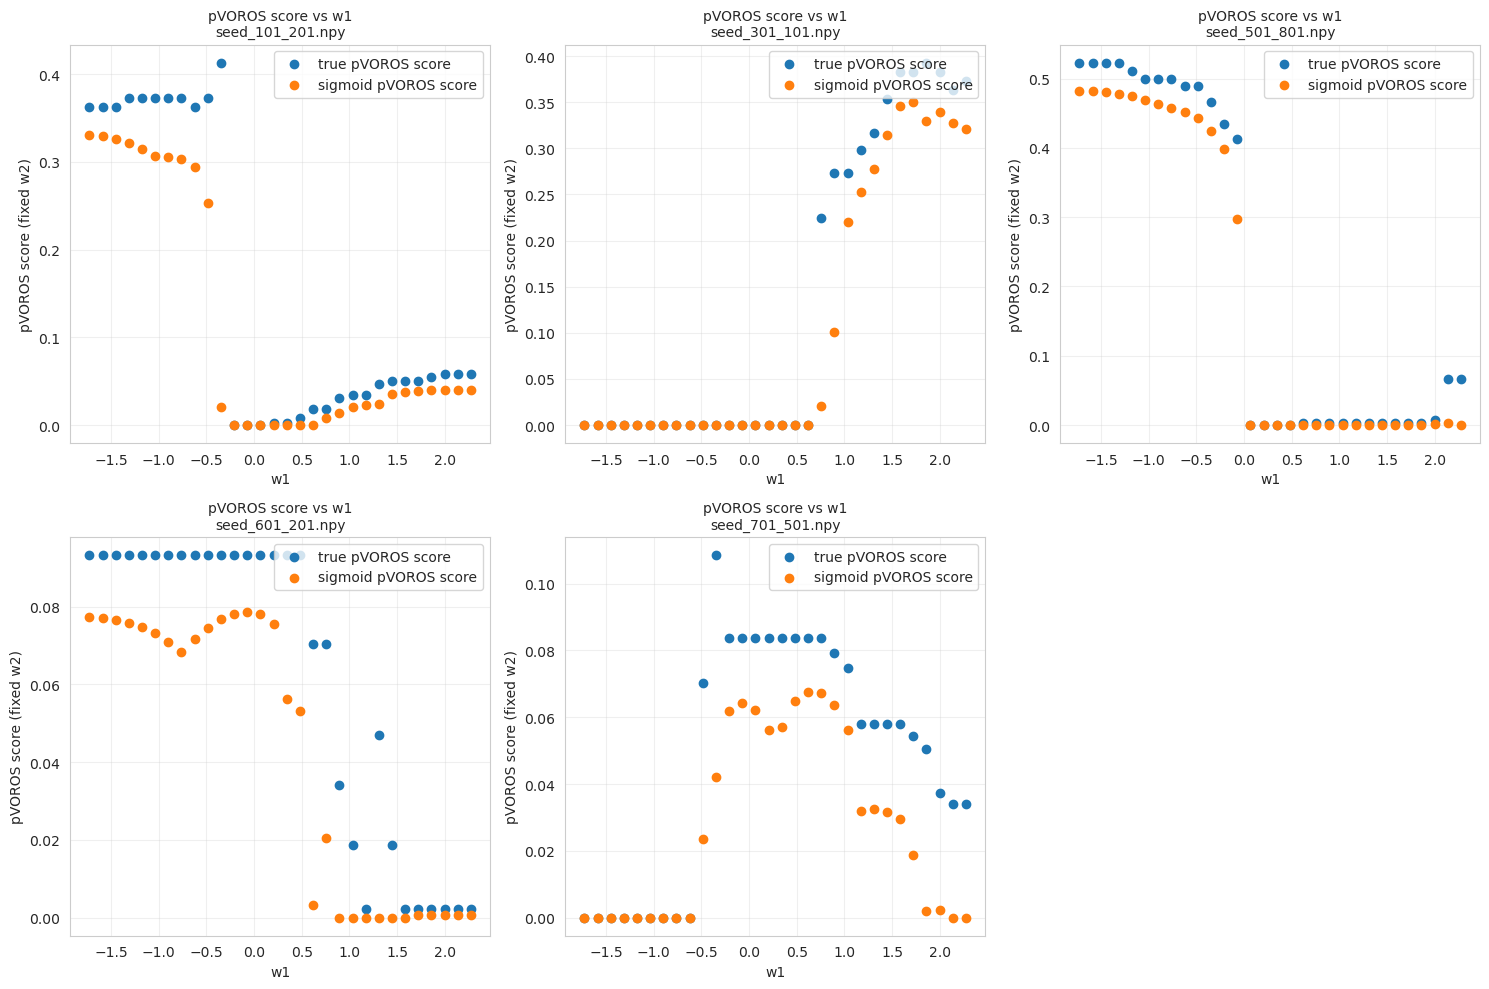

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

for ax, seed in zip(axs.flat, true_heatmaps):
    heatmap = true_heatmaps[seed]
    ax.scatter(w1_vals, heatmap[15], color='tab:blue', label='true pVOROS score')
    ax.scatter(w1_vals, sigmoid_heatmaps[seed][15], color='tab:orange', label='sigmoid pVOROS score')
    ax.set_xlabel('w1')
    ax.set_ylabel('pVOROS score (fixed w2)')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    ax.set_title(f"pVOROS score vs w1\n{seed}", fontsize=10)

axs.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

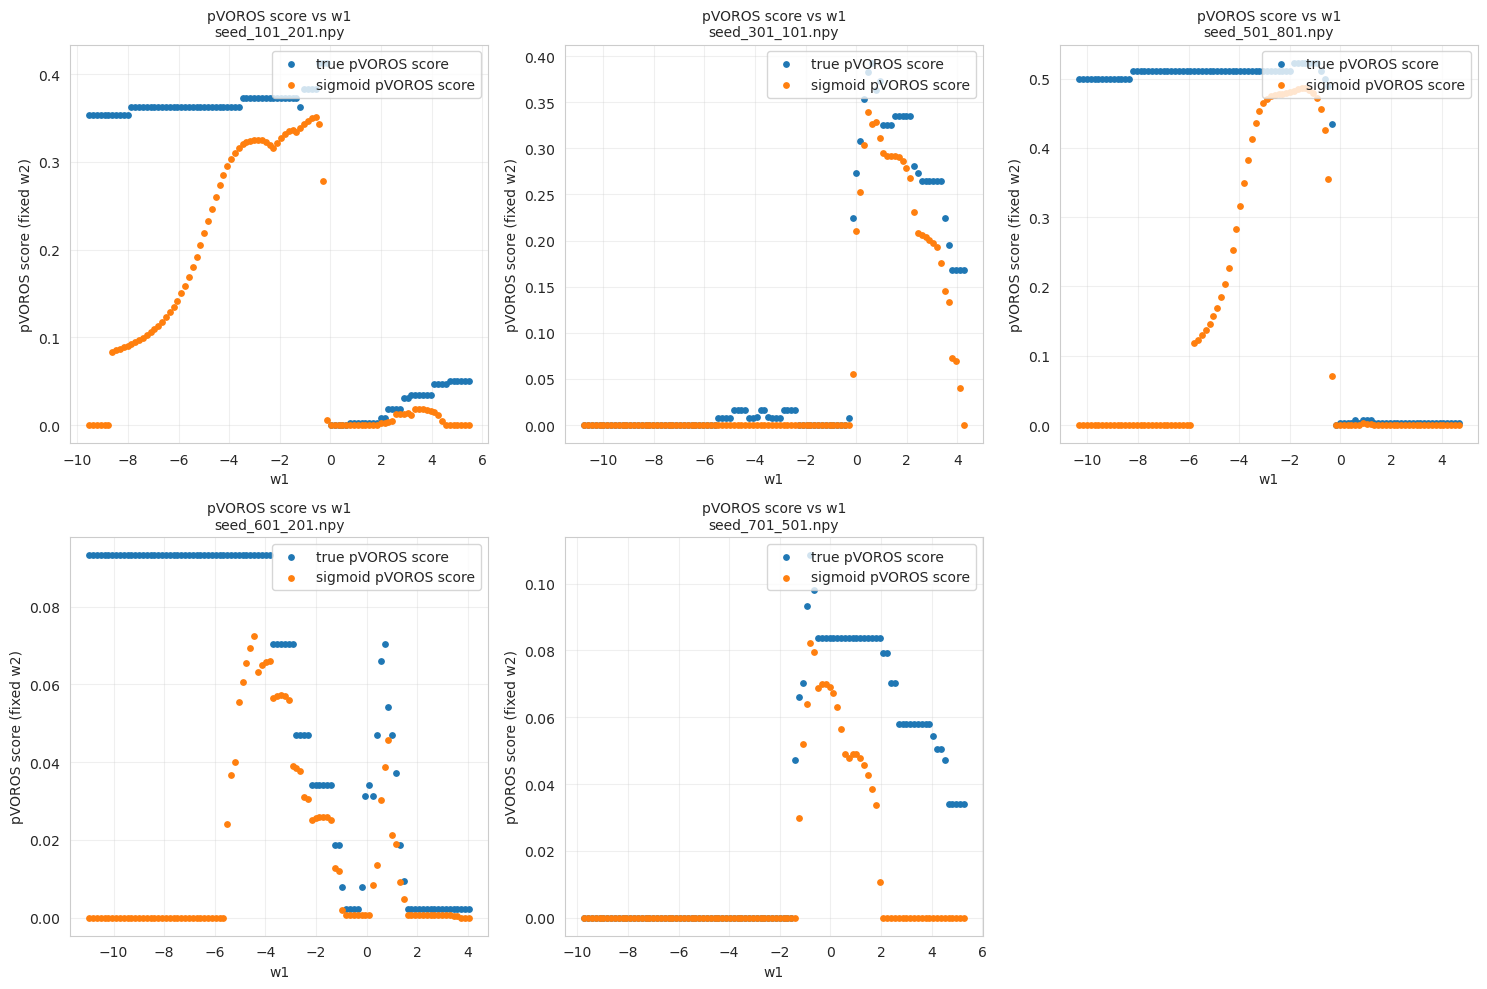

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
true_w1 = {}
sigmoid_w1 = {}

offset = {'seed_101_201.npy': 0.4, 
          'seed_301_101.npy': 0.4, 
          'seed_501_801.npy': -0.6, 
          'seed_601_201.npy': -0.5, 
          'seed_701_501.npy': 1.0}

for ax, seed in zip(axs.flat, clfs):
    y_true = train_test[seed][3]  # Shape: (N,)
    X_test = train_test[seed][1]  # Shape: (N, 2)
    
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    # Grab centers
    w1_center = clfs[seed].coef_[0, 0]
    w2_fixed = clfs[seed].coef_[0, 1] + offset[seed] # Strictly fixed w2
    intercept = float(clfs[seed].intercept_[0])

    # 1D array of w1 variations
    w1_vals = np.linspace(w1_center - 10, w1_center + 5, 100)

    # Initialize as 1D arrays to seamlessly match w1_vals
    heatmap = np.empty(len(w1_vals), dtype=float)
    s_heatmap = np.empty(len(w1_vals), dtype=float)

    # Extract features as 1D arrays
    x1 = X_test[:, 0]  # Shape: (N,)
    x2 = X_test[:, 1]  # Shape: (N,)

    # Compute predictions for all w1_vals simultaneously using broadcasting
    # x1[:, None] is (N, 1) multiplied by w1_vals (100,) results in (N, 100)
    Z = x1[:, None] * w1_vals + x2[:, None] * w2_fixed + intercept
    Y = sigmoid(Z)  # Shape: (N, 100)

    # Loop through each w1 step safely
    for j in range(len(w1_vals)):
        # Y[:, j] pulls a perfectly flat 1D array of length N
        heatmap[j] = pvoros_score(
            y_true,
            Y[:, j],
            alpha=0.6,
            kappa_frac=0.5,
            min_fp_cost_ratio=1/6,
            max_fp_cost_ratio=1/9,
        )
        s_heatmap[j] = sigmoid_pvoros_score(
            y_true,
            Y[:, j],
            alpha=0.6,
            kappa_frac=0.5,
            min_fp_cost_ratio=1/6,
            max_fp_cost_ratio=1/9,
            k=50
        )

    # Store results (if needed elsewhere)
    true_w1[seed] = heatmap
    sigmoid_w1[seed] = s_heatmap
    
    # Plotting (since they are both 1D arrays of length 100, this works perfectly)
    ax.scatter(w1_vals, heatmap, color='tab:blue', label='true pVOROS score', s=15)
    ax.scatter(w1_vals, s_heatmap, color='tab:orange', label='sigmoid pVOROS score', s=15)
    
    ax.set_xlabel('w1')
    ax.set_ylabel('pVOROS score (fixed w2)')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    ax.set_title(f"pVOROS score vs w1\n{seed}", fontsize=10)

axs.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# for ax, seed in zip(axs.flat, true_w1):
#     heatmap = true_w1[seed]
#     ax.scatter(w1_vals, heatmap, color='tab:blue', label='true pVOROS score')
#     ax.scatter(w1_vals, sigmoid_w1[seed], color='tab:orange', label='sigmoid pVOROS score')
#     ax.set_xlabel('w1')
#     ax.set_ylabel('pVOROS score (fixed w2)')
#     ax.legend(loc='upper right')
#     ax.grid(alpha=0.3)
#     ax.set_title(f"pVOROS score vs w1\n{seed}", fontsize=10)

# axs.flat[-1].set_visible(False)
# plt.tight_layout()
# plt.show()

## Testing JAX implementation of pVOROS score

In [ ]:
import _geometry
import _geometry_jax
import metrics
import metrics_jax

In [ ]:
for seed in clfs:
    x_test = train_test[seed][1]
    y_true = train_test[seed][3]
    y_pred = clfs[seed].predict_proba(x_test)[:, 1]



    score = metrics.pvoros_score(
        y_true,
        y_pred,
        alpha=0.6,
        kappa_frac=0.5,
        min_fp_cost_ratio=1/6,
        max_fp_cost_ratio=1/9,
    )
    print("pVOROS score:", score)

    test_score = metrics_jax.pvoros_score_jax(
        y_true,
        y_pred,
        alpha=0.6,
        kappa_frac=0.5,
        min_fp_cost_ratio=1/6,
        max_fp_cost_ratio=1/9,
    )
    print("testjax pVOROS score:", test_score)


pVOROS score: 0.01652892561983471
testjax pVOROS score: 0.016873279586434364
pVOROS score: 0.0
testjax pVOROS score: -0.0
pVOROS score: 0.0
testjax pVOROS score: -0.0
pVOROS score: 0.07031250000000001
testjax pVOROS score: 0.07098127156496048
pVOROS score: 0.08367768595041322
testjax pVOROS score: 0.08198137581348419
